*****************Adult Income Dataset (Census Income)*****************





In [ ]:
# import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve,
                             confusion_matrix,silhouette_score)

##Step 1: ****Data Preprocessing****

---



● Load both datasets.

In [ ]:

# Column names for the Adult dataset
adult_columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country",
    "income"
]
# URLs for the dataset
train_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
test_url  = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"

# Load training & test data
df_train = pd.read_csv( train_url,
    names=adult_columns,      # set column names
    na_values=" ?",           # treat " ?" as missing values
    skipinitialspace=True     # remove leading/trailing spaces
)
df_test = pd.read_csv(test_url,names=adult_columns,na_values=" ?",skipinitialspace=True,
    skiprows=1                # skip the first row (extra header in test file)
)

df = pd.concat([df_train, df_test], ignore_index=True)
df = df.sample(n=15000, random_state=42).reset_index(drop=True)
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,18,Private,423024,HS-grad,9,Never-married,Other-service,Not-in-family,White,Male,0,0,20,United-States,<=50K
1,17,Private,178953,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
2,25,Local-gov,348986,HS-grad,9,Never-married,Handlers-cleaners,Other-relative,Black,Male,0,0,40,United-States,<=50K
3,20,Private,218215,Some-college,10,Never-married,Sales,Own-child,White,Female,0,0,30,United-States,<=50K
4,47,Private,244025,HS-grad,9,Never-married,Machine-op-inspct,Unmarried,Amer-Indian-Eskimo,Male,0,0,56,Puerto-Rico,<=50K


● Handle missing values appropriately.

In [ ]:
df=df.dropna() #Handle missing values If we have missing
df = df.drop_duplicates() # If we have duplicates

● Split each dataset into training and testing sets (e.g., 70% train, 30% test).

In [ ]:
df["income"] = df["income"].replace(
    {"<=50K": 0, "<=50K.": 0, ">50K": 1, ">50K.": 1}
)

df["income"] = df["income"].astype(int)  # ensure numeric type

# Separate features and target
X = df.drop("income", axis=1)
y = df["income"]

X_train, X_test,y_train,y_test = train_test_split(X, y, test_size=0.3, stratify=y ,random_state=42)

/tmp/ipython-input-2003780767.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["income"] = df["income"].replace(


● For the Adult dataset, encode categorical variables using suitable encoding techniques
(e.g., one-hot encoding or label encoding).

 ● Normalize or standardize numerical features if required.

In [ ]:
# Identify numeric and categorical features
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

# Define transformers
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Transform training and test sets and all data to unsupervised
X_processed = preprocessor.fit_transform(X)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


● Data after cleaning (after Step 1)

Converting to a DataFrame allows to see all features alongside the target in a single, organized table, making it easier for viewing, analysis, or model training.

In [ ]:

X_train_df = pd.DataFrame(X_train_processed)
y_train_df = pd.Series(df['income'], name="target")

df_train = pd.concat([X_train_df, y_train_df], axis=1)

df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,99,100,101,102,103,104,105,106,107,target
0,0.538510,0.079478,1.128209,-0.139558,-0.223327,0.272965,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
1,-0.785546,0.544552,-1.195651,-0.139558,-0.223327,-0.046018,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
2,0.170717,-1.327502,2.290140,-0.139558,-0.223327,-0.843477,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
3,-0.932663,0.174876,1.128209,-0.139558,-0.223327,-2.438396,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
4,-1.153339,0.611708,-0.033721,-0.139558,-0.223327,-0.046018,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0


##Step 2: ****Model Building****

---

##Train at least two SVM classifiers:

 Tune basic hyperparameters (e.g., C, gamma, degree if polynomial). You can use
simple manual tuning or GridSearchCV/RandomizedSearchCV.

● One with a linear kernel.



In [ ]:
# Train SVM with linear kernel
svm_linear = SVC(kernel='linear', C=1,probability=True)
svm_linear.fit(X_train_processed, y_train)

SVC(C=1, kernel='linear', probability=True)

● one with a non-linear kernel (e.g., RBF or polynomial).

In [ ]:
 # Train SVM with RBF (non-linear) kernel
svm_rbf = SVC(kernel='rbf', C=1, gamma="scale", probability=True)
svm_rbf.fit(X_train_processed, y_train)


SVC(C=1, probability=True)

The Adult Income Dataset contains fixed numeric and categorical features with a binary target, so using C=1 and gamma="scale" produces a balanced and stable model without requiring major adjustments, performing well on this consistent data

● K-Means Clustering

◆ Apply K-Means with K = 2.
◆ Use the scaled features (no labels when fitting).


In [ ]:
# Train Kmeans
kmeans = KMeans(n_clusters=2, random_state=42,n_init=10)
kmeans_labels = kmeans.fit_predict(X_processed)

● Hierarchical Clustering

◆ Apply Hierarchical clustering with at least two linkage methods (e.g., single,
complete, average).

In [ ]:
# List of linkage methods
linkage_methods = ['average', 'ward']

# Dictionary to store labels
hc_labels_dict = {}

# Build models
for method in linkage_methods:
    hc = AgglomerativeClustering(n_clusters=2, linkage=method)
    labels = hc.fit_predict(X_processed)  # fit and predict clusters
    hc_labels_dict[method] = labels  # store the cluster labels

Average and Ward linkage are better than Single and Complete because they create more cohesive clusters and reduce the impact of outliers, with Ward minimizing variance within each cluster and Average computing the average distance between points, while Single is very sensitive to outliers and Complete relies only on the farthest point; this approach is supported in data mining literature such as “Introduction to Data Mining” by Tan et al. (2018)

##Step 3: ****Model Evaluation and Visualization****

A. SVM Evaluation (Supervised)

● ○ Predict class labels.

In [ ]:
y_pred_linear = svm_linear.predict(X_test_processed)
y_pred_rbf = svm_rbf.predict(X_test_processed)

● Compute and report the following metrics for both models on each dataset:
○ Accuracy
○ Precision
○ Recall
○ F1-Score
○ ROC-AUC Score

In [ ]:
#  probabilities for ROC-AUC
y_prob_linear = svm_linear.predict_proba(X_test_processed)[:, 1]
y_prob_rbf = svm_rbf.predict_proba(X_test_processed)[:, 1]

# Function to evaluation metrics
def print_metrics(y_true, y_pred, y_prob, model_name):
    print(f"--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-Score:", f1_score(y_true, y_pred))
    print("ROC-AUC Score:", roc_auc_score(y_true, y_prob))
    print()
# Print metrics for models
# Print metrics for models
print_metrics(y_test, y_pred_linear, y_prob_linear, "Linear SVM")
print_metrics(y_test, y_pred_rbf, y_prob_rbf, "RBF SVM")


--- Linear SVM ---
Accuracy: 0.8486666666666667
Precision: 0.7431629013079667
Recall: 0.573394495412844
F1-Score: 0.647332988089073
ROC-AUC Score: 0.9005222093680219

--- RBF SVM ---
Accuracy: 0.8555555555555555
Precision: 0.7663438256658596
Recall: 0.5807339449541284
F1-Score: 0.6607515657620042
ROC-AUC Score: 0.8985611665635342



● Plot ROC curves for both models on each dataset, overlaying them for direct
comparison.

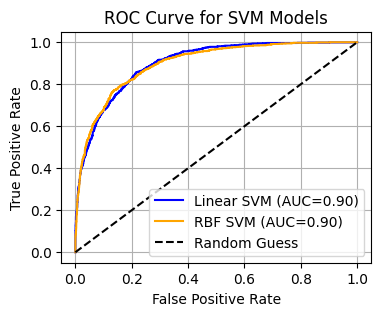

In [ ]:
# False Positive Rate & True Positive Rate
fpr_linear_svm, tpr_linear_svm, _ = roc_curve(y_test, y_prob_linear)
fpr_rbf_svm, tpr_rbf_svm, _ = roc_curve(y_test, y_prob_rbf)
# Plot ROC Curve
plt.figure(figsize=(4,3))
plt.plot(fpr_linear_svm, tpr_linear_svm, label=f'Linear SVM (AUC={roc_auc_score(y_test, y_prob_linear):.2f})', color='blue')
plt.plot(fpr_rbf_svm, tpr_rbf_svm, label=f'RBF SVM (AUC={roc_auc_score(y_test, y_prob_rbf):.2f})', color='orange')
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVM Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


● Generate and analyse confusion matrices for each model and dataset

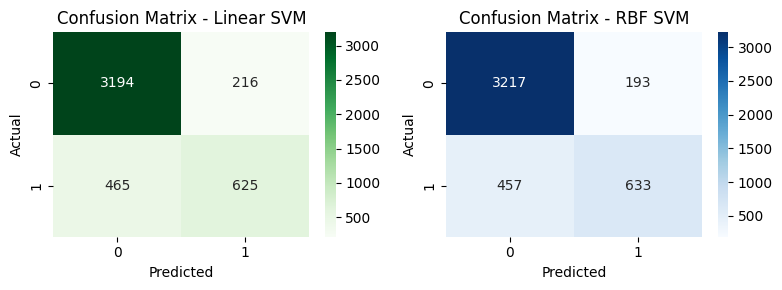

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8,3))

# Linear SVM
cm_linear_svm = confusion_matrix(y_test, y_pred_linear)
sns.heatmap(cm_linear_svm, annot=True, fmt='d', cmap='Greens', ax=axes[0])
axes[0].set_title('Confusion Matrix - Linear SVM')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# RBF SVM
cm_rbf_svm = confusion_matrix(y_test, y_pred_rbf)
sns.heatmap(cm_rbf_svm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix - RBF SVM')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

Although Accuracy and ROC-AUC are similar between Linear and RBF SVM, the Confusion Matrix shows that RBF SVM performs better at identifying the positive class (>50K), reducing false negatives (FN=457 vs 465) and increasing true positives (TP=633 vs 625) compared to Linear SVM, with only a slight increase in false positives (FP=193 vs 216). This indicates that RBF is more effective at capturing the minority class, even if the overall Accuracy and ROC-AUC differences are small.

----------------------------------------
B. Clustering Evaluation (Unsupervised)

In [ ]:
# Silhouette Score for K-Means
sil_kmeans = silhouette_score(X_processed, kmeans_labels)
print(f'Silhouette Score (K-Means): {sil_kmeans:.3f}')

# Table comparing K-Means clusters vs true labels
cm_kmeans = pd.crosstab(kmeans_labels, y)
print('\nK-Means Clusters vs True Labels:\n', cm_kmeans)

Silhouette Score (K-Means): 0.105

K-Means Clusters vs True Labels:
 income     0     1
row_0             
0       4371  3238
1       6995   394


In [ ]:
# Evaluate Hierarchical Clustering
for method in linkage_methods:
    labels = hc_labels_dict[method]
    # Silhouette Score
    sil = silhouette_score(X_processed, labels)
    print(f'Silhouette Score ({method} linkage): {sil:.3f}')
    # Table comparing clusters vs true labels
    cm_hc = pd.crosstab(labels, y)
    print(f'\nHierarchical Clusters ({method} linkage) vs True Labels:\n', cm_hc)

Silhouette Score (average linkage): 0.693

Hierarchical Clusters (average linkage) vs True Labels:
 income      0     1
row_0              
0       11366  3553
1           0    79
Silhouette Score (ward linkage): 0.343

Hierarchical Clusters (ward linkage) vs True Labels:
 income      0     1
row_0              
0       11015  3290
1         351   342


• Use PCA to 2D and plot:


In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)


Data colored by true labels

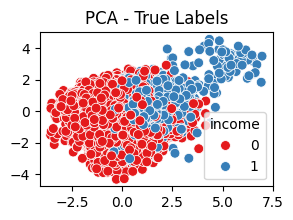

In [ ]:
plt.figure(figsize=(3,2))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='Set1', s=50)
plt.title('PCA - True Labels')
plt.show()

Data colored by K-Means clusters

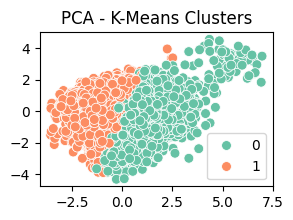

In [ ]:
plt.figure(figsize=(3,2))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=kmeans_labels, palette='Set2', s=50)
plt.title('PCA - K-Means Clusters')
plt.show()

Data colored by Hierarchical clusters

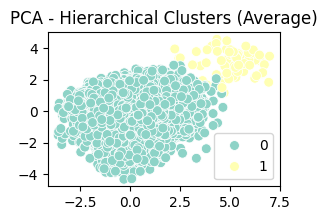

In [ ]:
plt.figure(figsize=(3,2))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=hc_labels_dict['average'],
                palette='Set3', s=50)
plt.title('PCA - Hierarchical Clusters (Average)')
plt.show()



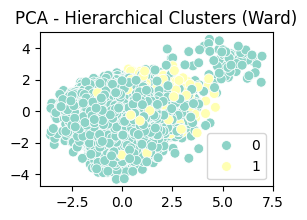

In [ ]:
plt.figure(figsize=(3,2))

sns.scatterplot( x=X_pca[:, 0], y=X_pca[:, 1], hue=hc_labels_dict['ward'],
   palette='Set3',
    s=50
)
plt.title('PCA - Hierarchical Clusters (Ward)')
plt.show()
